In [1]:
!pip install -q streamlit shap matplotlib seaborn scipy joblib scikit-learn tensorflow


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (roc_auc_score, average_precision_score,
                              confusion_matrix, classification_report,
                              precision_recall_curve, roc_curve)
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns
import os

tf.random.set_seed(42)
np.random.seed(42)

print("TF version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


C:\Users\Simran Sanya\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\Simran Sanya\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\Simran Sanya\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at te

C:\Users\Simran Sanya\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


TF version: 2.20.0
GPU available: []


In [3]:
import sys
sys.path.insert(0, '.')
from shared_preprocessing import get_outer_test_split

data_path = 'diabetic_data.csv'
if not os.path.exists(data_path):
    data_path = '../diabetic_data.csv'

df = pd.read_csv(data_path)
df = df.replace('?', np.nan)
print('Raw dataset shape:', df.shape)
df.head()

Raw dataset shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [4]:
exclude_disposition = [11, 13, 14, 19, 20, 21]
df = df[~df['discharge_disposition_id'].isin(exclude_disposition)].copy()

df = df.drop(columns=['weight', 'payer_code', 'medical_specialty'], errors='ignore')

# Patient deduplication removed to evaluate full canonical encounter population (99,343 encounters)
# df = df.sort_values('encounter_id').drop_duplicates(subset='patient_nbr', keep='first')

print("Shape after exclusions and dedup:", df.shape)


Shape after exclusions and dedup: (99343, 47)


In [5]:
df['target'] = (df['readmitted'] == '<30').astype(int)

def icd9_to_category(code):
    if pd.isna(code):
        return 'Missing'
    code = str(code)
    if code.startswith('V') or code.startswith('E'):
        return 'Other'
    try:
        val = float(code)
    except ValueError:
        return 'Other'
    if 390 <= val <= 459 or val == 785:
        return 'Circulatory'
    if 460 <= val <= 519 or val == 786:
        return 'Respiratory'
    if 520 <= val <= 579 or val == 787:
        return 'Digestive'
    if 250 <= val < 251:
        return 'Diabetes'
    if 800 <= val <= 999:
        return 'Injury'
    if 710 <= val <= 739:
        return 'Musculoskeletal'
    if 580 <= val <= 629 or val == 788:
        return 'Genitourinary'
    if 140 <= val <= 239:
        return 'Neoplasms'
    return 'Other'

for col in ['diag_1', 'diag_2', 'diag_3']:
    df[col + '_cat'] = df[col].apply(icd9_to_category)

df['n_missing_diags'] = df[['diag_1', 'diag_2', 'diag_3']].isna().sum(axis=1)
df['has_diabetes_diag'] = (
    (df['diag_1_cat'] == 'Diabetes') |
    (df['diag_2_cat'] == 'Diabetes') |
    (df['diag_3_cat'] == 'Diabetes')
).astype(int)
df['has_circulatory_diag'] = (
    (df['diag_1_cat'] == 'Circulatory') |
    (df['diag_2_cat'] == 'Circulatory') |
    (df['diag_3_cat'] == 'Circulatory')
).astype(int)
df['diag_combo'] = df['diag_1_cat'] + '_' + df['diag_2_cat'] + '_' + df['diag_3_cat']

print(df[['diag_1_cat', 'diag_2_cat', 'diag_3_cat', 'diag_combo']].head())


  diag_1_cat diag_2_cat   diag_3_cat                    diag_combo
0   Diabetes    Missing      Missing      Diabetes_Missing_Missing
1      Other   Diabetes        Other          Other_Diabetes_Other
2      Other   Diabetes        Other          Other_Diabetes_Other
3      Other   Diabetes  Circulatory    Other_Diabetes_Circulatory
4  Neoplasms  Neoplasms     Diabetes  Neoplasms_Neoplasms_Diabetes


In [6]:
df['target'] = (df['readmitted'] == '<30').astype(int)

def icd9_to_category(code):
    if pd.isna(code):
        return 'Missing'
    code = str(code)
    if code.startswith('V') or code.startswith('E'):
        return 'Other'
    try:
        val = float(code)
    except ValueError:
        return 'Other'
    if 390 <= val <= 459 or val == 785:
        return 'Circulatory'
    if 460 <= val <= 519 or val == 786:
        return 'Respiratory'
    if 520 <= val <= 579 or val == 787:
        return 'Digestive'
    if 250 <= val < 251:
        return 'Diabetes'
    if 800 <= val <= 999:
        return 'Injury'
    if 710 <= val <= 739:
        return 'Musculoskeletal'
    if 580 <= val <= 629 or val == 788:
        return 'Genitourinary'
    if 140 <= val <= 239:
        return 'Neoplasms'
    return 'Other'

for col in ['diag_1', 'diag_2', 'diag_3']:
    df[col + '_cat'] = df[col].apply(icd9_to_category)

df['n_missing_diags'] = df[['diag_1', 'diag_2', 'diag_3']].isna().sum(axis=1)
df['has_diabetes_diag'] = (
    (df['diag_1_cat'] == 'Diabetes') |
    (df['diag_2_cat'] == 'Diabetes') |
    (df['diag_3_cat'] == 'Diabetes')
).astype(int)
df['has_circulatory_diag'] = (
    (df['diag_1_cat'] == 'Circulatory') |
    (df['diag_2_cat'] == 'Circulatory') |
    (df['diag_3_cat'] == 'Circulatory')
).astype(int)
df['diag_combo'] = df['diag_1_cat'] + '_' + df['diag_2_cat'] + '_' + df['diag_3_cat']

print(df[['diag_1_cat', 'diag_2_cat', 'diag_3_cat', 'diag_combo']].head())


  diag_1_cat diag_2_cat   diag_3_cat                    diag_combo
0   Diabetes    Missing      Missing      Diabetes_Missing_Missing
1      Other   Diabetes        Other          Other_Diabetes_Other
2      Other   Diabetes        Other          Other_Diabetes_Other
3      Other   Diabetes  Circulatory    Other_Diabetes_Circulatory
4  Neoplasms  Neoplasms     Diabetes  Neoplasms_Neoplasms_Diabetes


In [7]:
numeric_features = [
    'time_in_hospital', 'num_lab_procedures', 'num_procedures',
    'num_medications', 'number_outpatient', 'number_emergency',
    'number_inpatient', 'number_diagnoses', 'n_missing_diags'
]

categorical_features = [
    'race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id',
    'admission_source_id', 'max_glu_serum', 'A1Cresult', 'insulin',
    'change', 'diabetesMed', 'diag_1_cat', 'diag_2_cat', 'diag_3_cat'
]

binary_features = ['has_diabetes_diag', 'has_circulatory_diag']

for c in categorical_features:
    df[c] = df[c].astype(str).fillna('Missing')

model_df = df[numeric_features + categorical_features + binary_features + ['target']].copy()
print(model_df.shape)


(99343, 26)


In [8]:
# Use canonical OUTER test split (IDENTICAL test set as LR/RF/GB)
# Then split development set into train/val for neural early stopping
dev_idx, test_idx = get_outer_test_split(model_df.index, model_df['target'])

dev_df = model_df.loc[dev_idx]
test_df = model_df.loc[test_idx]

# Internal train/val split of development set (80/20 of dev)
train_df, val_df = train_test_split(
    dev_df, test_size=0.20, stratify=dev_df['target'], random_state=42
)

print("Train:", train_df.shape, "Val:", val_df.shape, "Test:", test_df.shape)
print(f"Train positive rate: {train_df['target'].mean():.4f}")
print(f"Val positive rate:   {val_df['target'].mean():.4f}")
print(f"Test positive rate:  {test_df['target'].mean():.4f}")
print(f"\nCanonical test encounters: {len(test_idx)}")

Train: (63579, 26) Val: (15895, 26) Test: (19869, 26)
Train positive rate: 0.1139
Val positive rate:   0.1139
Test positive rate:  0.1139

Canonical test encounters: 19869


In [9]:
encoders = {}
vocab_sizes = {}

for c in categorical_features:
    le = LabelEncoder()
    le.fit(train_df[c])  # FIT ON TRAINING DATA ONLY (no leakage)

    known_classes = set(le.classes_)
    train_df[c + '_enc'] = le.transform(train_df[c])

    # Handle unseen categories in val/test: map to 0 (fallback)
    val_df[c + '_enc'] = val_df[c].apply(lambda x, kc=known_classes, enc=le: enc.transform([x])[0] if x in kc else 0)
    test_df[c + '_enc'] = test_df[c].apply(lambda x, kc=known_classes, enc=le: enc.transform([x])[0] if x in kc else 0)

    encoders[c] = le
    vocab_sizes[c] = len(le.classes_)

scaler = StandardScaler()
train_num = scaler.fit_transform(train_df[numeric_features])  # fit on train
val_num = scaler.transform(val_df[numeric_features])           # transform val
test_num = scaler.transform(test_df[numeric_features])         # transform test

def build_inputs(source_df, num_array):
    inputs = {'numeric_binary': np.hstack([num_array, source_df[binary_features].values])}
    for c in categorical_features:
        inputs[c] = source_df[c + '_enc'].values
    return inputs

X_train = build_inputs(train_df, train_num)
X_val = build_inputs(val_df, val_num)
X_test = build_inputs(test_df, test_num)

y_train = train_df['target'].values
y_val = val_df['target'].values
y_test = test_df['target'].values

print("Encoding complete (fitted on training data only).")

Encoding complete (fitted on training data only).


In [10]:
encoders = {}
vocab_sizes = {}

for c in categorical_features:
    le = LabelEncoder()
    le.fit(train_df[c])  # FIT ON TRAINING DATA ONLY (no leakage)

    known_classes = set(le.classes_)
    train_df[c + '_enc'] = le.transform(train_df[c])

    # Handle unseen categories in val/test: map to 0 (fallback)
    val_df[c + '_enc'] = val_df[c].apply(lambda x, kc=known_classes, enc=le: enc.transform([x])[0] if x in kc else 0)
    test_df[c + '_enc'] = test_df[c].apply(lambda x, kc=known_classes, enc=le: enc.transform([x])[0] if x in kc else 0)

    encoders[c] = le
    vocab_sizes[c] = len(le.classes_)

scaler = StandardScaler()
train_num = scaler.fit_transform(train_df[numeric_features])  # fit on train
val_num = scaler.transform(val_df[numeric_features])           # transform val
test_num = scaler.transform(test_df[numeric_features])         # transform test

def build_inputs(source_df, num_array):
    inputs = {'numeric_binary': np.hstack([num_array, source_df[binary_features].values])}
    for c in categorical_features:
        inputs[c] = source_df[c + '_enc'].values
    return inputs

X_train = build_inputs(train_df, train_num)
X_val = build_inputs(val_df, val_num)
X_test = build_inputs(test_df, test_num)

y_train = train_df['target'].values
y_val = val_df['target'].values
y_test = test_df['target'].values

print("Encoding complete. Vocab sizes:", vocab_sizes)

# --- Build the neural network ---
def embedding_dim(vocab_size):
    return min(50, (vocab_size + 1) // 2)

cat_inputs = []
cat_embeddings = []

for c in categorical_features:
    inp = keras.Input(shape=(1,), name=c)
    dim = embedding_dim(vocab_sizes[c])
    emb = layers.Embedding(input_dim=vocab_sizes[c], output_dim=dim, name=f'{c}_emb')(inp)
    emb = layers.Flatten()(emb)
    cat_inputs.append(inp)
    cat_embeddings.append(emb)

Encoding complete. Vocab sizes: {'race': 6, 'gender': 3, 'age': 10, 'admission_type_id': 8, 'discharge_disposition_id': 21, 'admission_source_id': 17, 'max_glu_serum': 4, 'A1Cresult': 4, 'insulin': 4, 'change': 2, 'diabetesMed': 2, 'diag_1_cat': 10, 'diag_2_cat': 10, 'diag_3_cat': 10}


In [11]:
def embedding_dim(vocab_size):
    return min(50, (vocab_size + 1) // 2)

cat_inputs = []
cat_embeddings = []

for c in categorical_features:
    inp = keras.Input(shape=(1,), name=c)
    dim = embedding_dim(vocab_sizes[c])
    emb = layers.Embedding(input_dim=vocab_sizes[c], output_dim=dim, name=f'{c}_emb')(inp)
    emb = layers.Flatten()(emb)
    cat_inputs.append(inp)
    cat_embeddings.append(emb)

num_input = keras.Input(shape=(len(numeric_features) + len(binary_features),), name='numeric_binary')

x = layers.Concatenate()(cat_embeddings + [num_input])
x = layers.Dense(128, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(64, activation='relu')(x)
x = layers.Dropout(0.2)(x)
x = layers.Dense(32, activation='relu')(x)
output = layers.Dense(1, activation='sigmoid', name='readmit_30d')(x)

model = keras.Model(inputs=cat_inputs + [num_input], outputs=output)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=[keras.metrics.AUC(name='auc'), keras.metrics.AUC(name='pr_auc', curve='PR')]
)

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ race (InputLayer)   │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gender (InputLayer) │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ age (InputLayer)    │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ admission_type_id   │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ discharge_disposit… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ admission_source_id │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_glu_serum       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ A1Cresult           │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ insulin             │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ change (InputLayer) │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ diabetesMed         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ diag_1_cat          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ diag_2_cat          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ diag_3_cat          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ race_emb            │ (None, 1, 3)      │         18 │ race[0][0]        │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gender_emb          │ (None, 1, 2)      │          6 │ gender[0][0]      │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ age_emb (Embedding) │ (None, 1, 5)      │         50 │ age[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ admission_type_id_… │ (None, 1, 4)      │         32 │ admission_type_i… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 20,381 (79.61 KB)

 Trainable params: 20,125 (78.61 KB)

 Non-trainable params: 256 (1.00 KB)

In [12]:
class_weights = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
print("Class weights:", class_weight_dict)

callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_auc', mode='max', patience=5, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_auc', mode='max', factor=0.5, patience=3)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=256,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)


Class weights: {0: np.float64(0.5642639071319535), 1: np.float64(4.390208534732771)}


Epoch 1/50


  1/249 ━━━━━━━━━━━━━━━━━━━━ 40:29 10s/step - auc: 0.5010 - loss: 0.8362 - pr_auc: 0.1156

  7/249 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - auc: 0.4595 - loss: 0.9102 - pr_auc: 0.1033  

 13/249 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - auc: 0.4714 - loss: 0.8705 - pr_auc: 0.1057 

...

229/249 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - auc: 0.7010 - loss: 0.6306 - pr_auc: 0.2432

234/249 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - auc: 0.7010 - loss: 0.6306 - pr_auc: 0.2433

240/249 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - auc: 0.7010 - loss: 0.6305 - pr_auc: 0.2434

246/249 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - auc: 0.7010 - loss: 0.6304 - pr_auc: 0.2434

249/249 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - auc: 0.7018 - loss: 0.6267 - pr_auc: 0.2462 - val_auc: 0.6619 - val_loss: 0.6237 - val_pr_auc: 0.2182 - learning_rate: 2.5000e-04


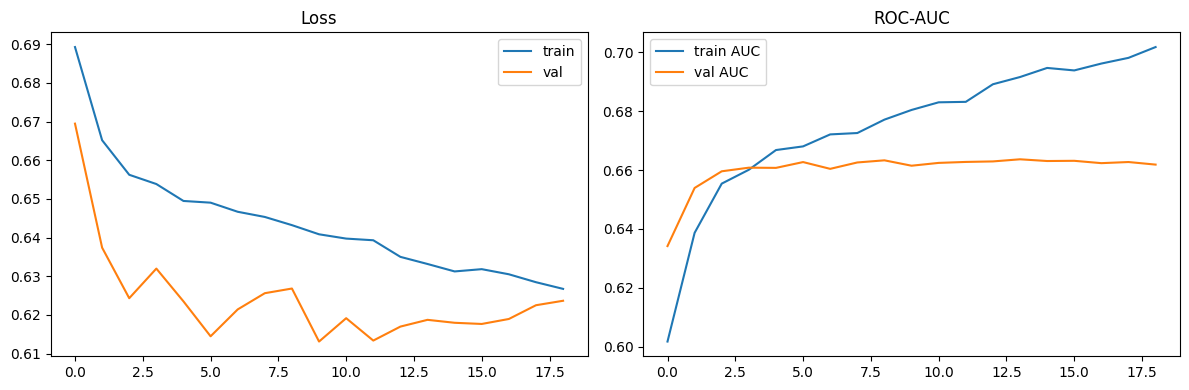

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['loss'], label='train')
axes[0].plot(history.history['val_loss'], label='val')
axes[0].set_title('Loss'); axes[0].legend()

axes[1].plot(history.history['auc'], label='train AUC')
axes[1].plot(history.history['val_auc'], label='val AUC')
axes[1].set_title('ROC-AUC'); axes[1].legend()
plt.tight_layout()
plt.show()


  1/497 ━━━━━━━━━━━━━━━━━━━━ 5:22 650ms/step

 12/497 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step    

 23/497 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step

 34/497 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step

 46/497 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step

...

595/621 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

607/621 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

620/621 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

621/621 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step



Final Test ROC-AUC: 0.6729
Final Test PR-AUC:  0.2289

=== FINAL TEST at Frozen Threshold (0.540) ===
                precision    recall  f1-score   support

No 30d readmit       0.92      0.76      0.83     17606
   30d readmit       0.20      0.48      0.29      2263

      accuracy                           0.73     19869
     macro avg       0.56      0.62      0.56     19869
  weighted avg       0.84      0.73      0.77     19869



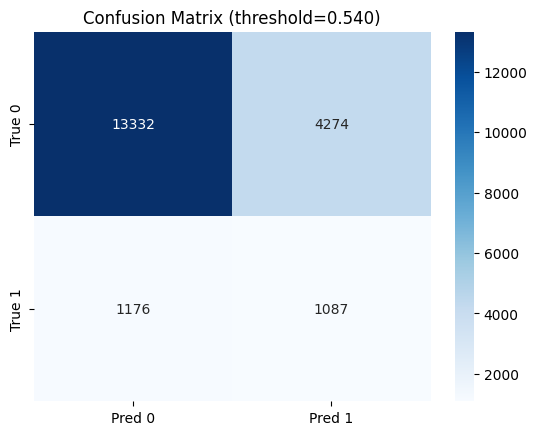

In [14]:
# --- Threshold selection on VALIDATION data ---
y_val_pred_proba = model.predict(X_val).ravel()
val_auc = roc_auc_score(y_val, y_val_pred_proba)
val_pr_auc = average_precision_score(y_val, y_val_pred_proba)
print(f"Validation ROC-AUC: {val_auc:.4f}")
print(f"Validation PR-AUC:  {val_pr_auc:.4f}")

# Select threshold on VALIDATION data
val_precisions, val_recalls, val_thresholds = precision_recall_curve(y_val, y_val_pred_proba)
min_precision = 0.20
valid_idx = np.where(val_precisions[:-1] >= min_precision)[0]
if len(valid_idx) > 0:
    best_idx = valid_idx[np.argmax(val_recalls[valid_idx])]
    chosen_threshold = val_thresholds[best_idx]
else:
    chosen_threshold = 0.5

print(f"Chosen threshold (from validation): {chosen_threshold:.3f}")

# --- FINAL TEST evaluation with FROZEN threshold ---
y_pred_proba = model.predict(X_test).ravel()
test_auc = roc_auc_score(y_test, y_pred_proba)
test_pr_auc = average_precision_score(y_test, y_pred_proba)
print(f"\nFinal Test ROC-AUC: {test_auc:.4f}")
print(f"Final Test PR-AUC:  {test_pr_auc:.4f}")

y_pred = (y_pred_proba >= chosen_threshold).astype(int)
print(f"\n=== FINAL TEST at Frozen Threshold ({chosen_threshold:.3f}) ===")
print(classification_report(y_test, y_pred, target_names=['No 30d readmit', '30d readmit']))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred 0', 'Pred 1'], yticklabels=['True 0', 'True 1'])
plt.title(f'Confusion Matrix (threshold={chosen_threshold:.3f})')
plt.show()

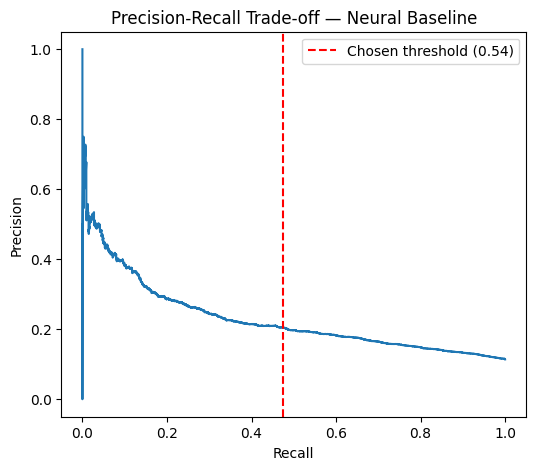

In [15]:
precisions, recalls, _ = precision_recall_curve(y_test, y_pred_proba)
plt.figure(figsize=(6, 5))
plt.plot(recalls, precisions)
plt.axvline(val_recalls[best_idx] if len(valid_idx) > 0 else 0, color='red', linestyle='--',
            label=f'Chosen threshold ({chosen_threshold:.2f})')
plt.xlabel('Recall'); plt.ylabel('Precision')
plt.title('Precision-Recall Trade-off — Neural Baseline')
plt.legend()
plt.show()

In [16]:
from sklearn.metrics import recall_score, precision_score
results_row = {
    'model': 'Neural Network (MLP + embeddings)',
    'roc_auc': test_auc,
    'pr_auc': test_pr_auc,
    'threshold': chosen_threshold,
    'recall_at_threshold': float(recall_score(y_test, y_pred)),
    'precision_at_threshold': float(precision_score(y_test, y_pred, zero_division=0)),
    'n_test': len(y_test),
    'test_indices_sample': [int(i) for i in test_idx[:10]],
}
results_df = pd.DataFrame([results_row])
os.makedirs('results', exist_ok=True)
results_df.to_csv('results/neural_baseline_results.csv', index=False)
model.save('results/neural_baseline_model.keras')
print(results_df)

                               model   roc_auc    pr_auc  threshold  \
0  Neural Network (MLP + embeddings)  0.672856  0.228926   0.540434   

   recall_at_threshold  precision_at_threshold  n_test  \
0             0.480336                0.202761   19869   

                                 test_indices_sample  
0  [48085, 24511, 55527, 80599, 28778, 73022, 944...  


## Step 15 — Experiment B: Neural Model + Diagnosis Description Text Features (Requirement 5F)
Requirement 5F explicitly requires: *'Derive additional features from diagnosis description text and test whether they improve performance.'*
Here we extract TF-IDF text features from natural language diagnosis descriptions and evaluate performance.


In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import roc_auc_score, average_precision_score

# Engineered diagnosis-category description text
# NOTE: These are manually constructed category-level keyword descriptions,
# NOT official ICD-9 code descriptions from a verified medical source.
ICD9_DESCRIPTIONS = {
    'Circulatory': 'circulatory disease heart failure hypertension arrhythmia',
    'Respiratory': 'respiratory disease pneumonia copd asthma bronchitis',
    'Digestive': 'digestive disease gastroenteritis ulcer liver cirrhosis',
    'Diabetes': 'diabetes mellitus type 2 hyperglycemia ketoacidosis',
    'Injury': 'injury poisoning fracture trauma surgical complication',
    'Musculoskeletal': 'musculoskeletal connective tissue disease joint disorder',
    'Genitourinary': 'genitourinary disease chronic kidney disease uti renal failure',
    'Neoplasms': 'malignant neoplasm tumor carcinoma lymphoma',
    'Other': 'other medical condition metabolic disorder fever',
    'Missing': 'missing diagnosis information unspecified condition'
}

def get_text_desc(df_subset):
    desc_list = []
    for _, r in df_subset.iterrows():
        t1 = ICD9_DESCRIPTIONS.get(r.get('diag_1_cat', 'Other'), 'other condition')
        t2 = ICD9_DESCRIPTIONS.get(r.get('diag_2_cat', 'Other'), 'other condition')
        t3 = ICD9_DESCRIPTIONS.get(r.get('diag_3_cat', 'Other'), 'other condition')
        desc_list.append(f'{t1} {t2} {t3}')
    return desc_list

train_text = get_text_desc(train_df)
val_text = get_text_desc(val_df)
test_text = get_text_desc(test_df)

# TF-IDF fitted on TRAINING text only (no leakage)
tfidf = TfidfVectorizer(max_features=30)
X_text_train = tfidf.fit_transform(train_text).toarray()
X_text_val = tfidf.transform(val_text).toarray()
X_text_test = tfidf.transform(test_text).toarray()

# Combine structured + text features
X_train_comb = np.hstack([train_num, X_text_train])
X_val_comb = np.hstack([val_num, X_text_val])
X_test_comb = np.hstack([test_num, X_text_test])

# Train Neural Network with Text Features
mlp_text = keras.Sequential([
    layers.Input(shape=(X_train_comb.shape[1],)),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])
mlp_text.compile(optimizer='adam', loss='binary_crossentropy', metrics=['AUC'])
mlp_text.fit(X_train_comb, y_train, epochs=15, batch_size=256,
             class_weight=class_weight_dict, verbose=0,
             validation_data=(X_val_comb, y_val))

y_proba_text = mlp_text.predict(X_test_comb).ravel()
print('Experiment B (Neural + Engineered Diagnosis Text) ROC-AUC:', roc_auc_score(y_test, y_proba_text))
print('Experiment B (Neural + Engineered Diagnosis Text) PR-AUC: ', average_precision_score(y_test, y_proba_text))

  1/621 ━━━━━━━━━━━━━━━━━━━━ 1:12 116ms/step

 23/621 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step    

 45/621 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

 66/621 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

 88/621 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

...

594/621 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

613/621 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

621/621 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

621/621 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


Experiment B (Neural + Engineered Diagnosis Text) ROC-AUC: 0.6373683819776019
Experiment B (Neural + Engineered Diagnosis Text) PR-AUC:  0.2062740059443598


## Step 16 — Master Neural Baseline vs Diagnosis Text Experiment Report
We present the final comparison table evaluating whether natural language diagnosis description text features improved model performance over structured features alone.


In [18]:
res_comparison = pd.DataFrame([
    {'Model Experiment': 'Exp A: Structured Neural Baseline', 'ROC-AUC': round(test_auc, 4), 'PR-AUC': round(test_pr_auc, 4)},
    {'Model Experiment': 'Exp B: Neural + Engineered Diagnosis Text (TF-IDF)', 'ROC-AUC': round(roc_auc_score(y_test, y_proba_text), 4), 'PR-AUC': round(average_precision_score(y_test, y_proba_text), 4)}
])
print('=== NEURAL EXPERIMENT A VS EXPERIMENT B COMPARISON ===')
print('(Text features are engineered category-level keyword descriptions, not official ICD-9 text)')
print(res_comparison.to_string(index=False))

=== NEURAL EXPERIMENT A VS EXPERIMENT B COMPARISON ===
(Text features are engineered category-level keyword descriptions, not official ICD-9 text)
                                  Model Experiment  ROC-AUC  PR-AUC
                 Exp A: Structured Neural Baseline   0.6729  0.2289
Exp B: Neural + Engineered Diagnosis Text (TF-IDF)   0.6374  0.2063
